### **Algoritmo de Kruskal**
El algoritmo de Kruskal construye el MST seleccionando aristas desde el más bajo hasta el más alto, siempre que no formen ciclos.

**Proceso:**
- Ordenar todas las aristas por peso (de menor a mayor).
- Empezar desde la arista de menor peso y, si añadirla no forma un ciclo en el grafo, incluirla en el MST.
- Continuar hasta que se hayan añadido 𝑉−1 (donde𝑉 es el número de vértices).

In [37]:
import sys
import os

dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(dir, os.pardir))
sys.path.append(root_dir)

from utils import graphs
from utils.disjoinset import DisjointSet

In [38]:
%%file 1.graph
1 4 2 8 3 5 4 8
0 4 3 8 5 9 6 1
0 8 4 2 5 5 6 1
0 5 1 8 5 7 7 4
0 8 2 2 6 1 7 6
1 9 2 5 3 7
1 1 2 1 4 1
3 4 4 6

Overwriting 1.graph


In [39]:
# Leer el grafo desde el archivo 1.graph
with open('1.graph') as f:
    G = []
    for line in f:
        if line.startswith('-'):
            G.append([])
            continue
        nums = list(map(int, line.split()))
        G.append([(nums[i], nums[i+1]) for i in range(0, len(nums), 2)])


[[(1, 4), (2, 8), (3, 5), (4, 8)], [(0, 4), (3, 8), (5, 9), (6, 1)], [(0, 8), (4, 2), (5, 5), (6, 1)], [(0, 5), (1, 8), (5, 7), (7, 4)], [(0, 8), (2, 2), (6, 1), (7, 6)], [(1, 9), (2, 5), (3, 7)], [(1, 1), (2, 1), (4, 1)], [(3, 4), (4, 6)]]


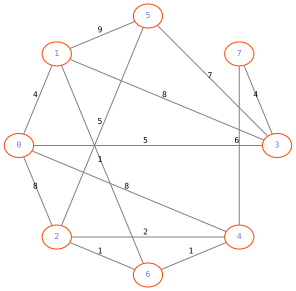

In [40]:
graphs.show(G, weighted=True, layout='circo')

In [41]:
import heapq

def kruskal(G):
    n = len(G)
    edges = []

    for u in range(n):
        for v, w in G[u]:
            heapq.heappush(edges, (w, u, v))

    ds = DisjointSet(n)
    mst = []

    while len(mst) < n-1:
        _, u, v = heapq.heappop(edges)
        if not ds.sameset(u, v):
            ds.union(u, v) 
            mst.append((u, v))

    path = [-1]*n
    for u, v in mst:
        if path[v] == -1: 
            path[v] = u
        else:
            path[u] = v

    return path

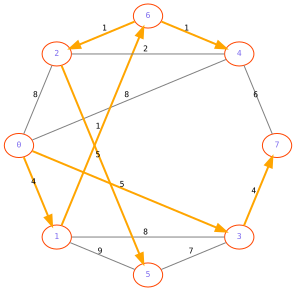

In [42]:
path = kruskal(G)
graphs.show(G, weighted=True, layout='circo', path=path)